<a href="https://colab.research.google.com/github/Existanze54/sirius-neural-networks-2026/blob/main/Seminars/S03_CNNs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Нейронные сети в биоинформатике

### Семинар 3: Конволюционные нейронные сети

# MedMNIST - классификация изображений клеток

В этом семинаре мы поработаем с игрушечным датасетом медицинских изображений - medmnist

In [ ]:
!pip install medmnist

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 5.8 MB/s eta 0:00:00


Пример работы с bloodmnist

In [ ]:
from tqdm import tqdm
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.utils.data as data
import torchvision.transforms as transforms
import medmnist
from medmnist import INFO, Evaluator

In [ ]:
data_flag = 'bloodmnist'
download = True

NUM_EPOCHS = 3
BATCH_SIZE = 128
lr = 0.001

info = INFO[data_flag]
task = info['task']
n_channels = info['n_channels']
n_classes = len(info['label'])

DataClass = getattr(medmnist, info['python_class']) # same as medmnist.BloodMNIST

In [ ]:
device = torch.device("cuda:0") if torch.cuda.is_available() else torch.device("cpu")
device

device(type='cuda', index=0)

In [ ]:
info['python_class']

'BloodMNIST'

In [ ]:
medmnist.BloodMNIST

medmnist.dataset.BloodMNIST

In [ ]:
data_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[.5], std=[.5])
])

# load the data
train_dataset = DataClass(split='train',
                          transform=data_transform,
                          download=download)
test_dataset = DataClass(split='test',
                         transform=data_transform,
                         download=download)

pil_dataset = DataClass(split='train', download=download)

# encapsulate data into dataloader form
train_loader = data.DataLoader(dataset=train_dataset,
                               batch_size=BATCH_SIZE,
                               shuffle=True)
train_loader_at_eval = data.DataLoader(dataset=train_dataset,
                                       batch_size=2*BATCH_SIZE,
                                       shuffle=False)
test_loader = data.DataLoader(dataset=test_dataset,
                              batch_size=2*BATCH_SIZE,
                              shuffle=False)

100%|██████████| 35.5M/35.5M [00:02<00:00, 12.8MB/s]


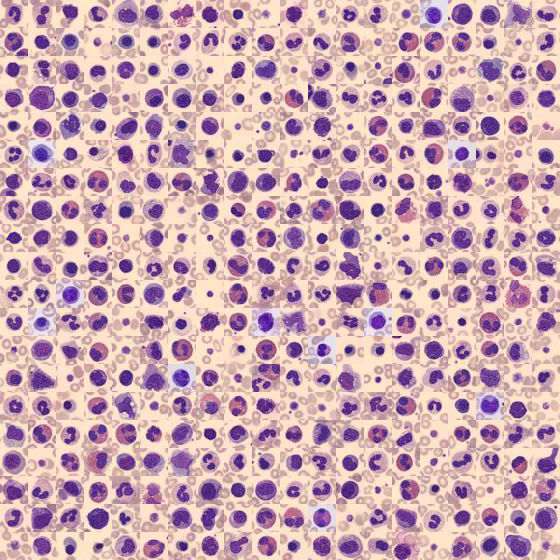

In [ ]:
train_dataset.montage(length=20)

In [ ]:
print(train_dataset)
print("===================")
print(test_dataset)

Dataset BloodMNIST of size 28 (bloodmnist)
    Number of datapoints: 11959
    Root location: /root/.medmnist
    Split: train
    Task: multi-class
    Number of channels: 3
    Meaning of labels: {'0': 'basophil', '1': 'eosinophil', '2': 'erythroblast', '3': 'immature granulocytes(myelocytes, metamyelocytes and promyelocytes)', '4': 'lymphocyte', '5': 'monocyte', '6': 'neutrophil', '7': 'platelet'}
    Number of samples: {'train': 11959, 'val': 1712, 'test': 3421}
    Description: The BloodMNIST is based on a dataset of individual normal cells, captured from individuals without infection, hematologic or oncologic disease and free of any pharmacologic treatment at the moment of blood collection. It contains a total of 17,092 images and is organized into 8 classes. We split the source dataset with a ratio of 7:1:2 into training, validation and test set. The source images with resolution 3×360×363 pixels are center-cropped into 3×200×200, and then resized into 3×28×28.
    License: CC B

Небольшой пример работы сверточного слоя с 3 входными и 2 выходными каналами.

<img src="https://i.stack.imgur.com/uwHol.gif" width="800">

In [ ]:
pil_dataset[0]

(<PIL.Image.Image image mode=RGB size=28x28>, array([7]))

In [ ]:
for X, y in train_loader:
  break

In [ ]:
X.shape, y.shape

(torch.Size([128, 3, 28, 28]), torch.Size([128, 1]))

In [ ]:
class Net(nn.Module):
    def __init__(self, in_channels, num_classes):

        # your code here

    def forward(self, x):

        # your code here
        return = # your code here

model = Net(in_channels=n_channels, num_classes=n_classes).to(device)

# define loss function and optimizer
if task == "multi-label, binary-class":
    criterion = nn.BCEWithLogitsLoss()
else:
    criterion = nn.CrossEntropyLoss()

optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9)

IndentationError: expected an indented block after function definition on line 2 (220318226.py, line 6)

In [ ]:
model(X).shape

In [ ]:
model(X[:5])

In [ ]:
import torch.nn.functional as F

In [ ]:
F.softmax(model(X[:5]), dim=1)

In [ ]:
device = torch.device("cuda:0")
model = model.to(device)

In [ ]:
for epoch in range(NUM_EPOCHS):

    model.train()
    for inputs, targets in tqdm(train_loader):

        inputs = inputs.to(device)
        targets = targets.to(device)

        # forward + backward + optimize
        optimizer.zero_grad()
        outputs = model(inputs)

        if task == 'multi-label, binary-class':
            targets = targets.to(torch.float32)
            loss = criterion(outputs, targets)
        else:
            targets = targets.squeeze()
            loss = criterion(outputs, targets)

        loss.backward()
        optimizer.step()

In [ ]:
def test(model, split):

    model.eval()
    y_score = torch.tensor([]).to(device)

    data_loader = train_loader_at_eval if split == 'train' else test_loader

    with torch.no_grad():
        for inputs, targets in data_loader:
            inputs = inputs.to(device)
            targets = targets.to(device)

            outputs = model(inputs)

            if task == 'multi-label, binary-class':
                targets = targets.to(torch.float32)
                outputs = outputs.softmax(dim=-1)
            else:
                targets = targets.squeeze()
                outputs = outputs.softmax(dim=-1)

            y_score = torch.cat((y_score, outputs), 0)

        y_score = y_score.cpu().detach().numpy()

        evaluator = Evaluator(data_flag, split)
        metrics = evaluator.evaluate(y_score)

        print('%s  auc: %.3f  acc:%.3f' % (split, *metrics))


print('==> Evaluating ...')
test(model, 'train')
test(model, 'test')

Попробуем увеличить количество сверток до 7-и

In [ ]:
# 7 CNN (with reduced channels) + Linear

class Net(nn.Module):
    def __init__(self, in_channels, num_classes, block_sizes=(16, 32, 64, 128, 256, 512, 1024)):
        super().__init__()

        # # you can add blocks to a nn.Sequential within a loop
        # cnn_blocks = []
        # cnn_blocks.append(nn.Sequential(
        #         nn.Conv2d(in_channels = in_channels,
        #                   out_channels = block_sizes[0],
        #                   kernel_size = 3),
        #         nn.ReLU()
        #         )
        # )
        # for i in range(len(block_sizes) - 1):
        #     cnn_blocks.append(nn.Sequential(
        #         nn.Conv2d(in_channels = block_sizes[i],
        #                   out_channels = block_sizes[i + 1],
        #                   kernel_size = 3),
        #         nn.ReLU()
        #         )
        #     )
        # self.featurizer = nn.Sequential(*cnn_blocks)

        self.featurizer = nn.Sequential(

            # your code here

        )

        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(1024, 8)
        )

    def forward(self, x):
        x = self.featurizer(x)
        x = self.head(x)
        return x

model = Net(in_channels=n_channels, num_classes=n_classes).to(device)

# define loss function and optimizer
if task == "multi-label, binary-class":
    criterion = nn.BCEWithLogitsLoss()
else:
    criterion = nn.CrossEntropyLoss()

optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9)

In [ ]:
model(X).shape

In [ ]:
for epoch in range(NUM_EPOCHS):

    model.train()
    for inputs, targets in tqdm(train_loader):

        inputs = inputs.to(device)
        targets = targets.to(device)

        # forward + backward + optimize
        optimizer.zero_grad()
        outputs = model(inputs)

        if task == 'multi-label, binary-class':
            targets = targets.to(torch.float32)
            loss = criterion(outputs, targets)
        else:
            targets = targets.squeeze()
            loss = criterion(outputs, targets)

        loss.backward()
        optimizer.step()

In [ ]:
print('==> Evaluating ...')
test(model, 'train')
test(model, 'test')

Вероятно, получим качество даже хуже, чем было.

К сожалению, если в нейронные сети добавлять много слоев без дополнительных модификаций, они могут хуже сходиться (обучаться).